# Modélisation Machine Learning - Prédiction de la Gravité des Accidents

Ce notebook utilise les données nettoyées du fichier BAAC 2024 pour entraîner et comparer plusieurs modèles de classification :
- **Logistic Regression** (baseline)
- **Random Forest** (bagging)
- **XGBoost** (boosting)
- **CatBoost** (boosting)
- **LightGBM** (boosting)

L'objectif est de prédire la gravité d'un accident pour un usager (`is_grave` : Accident mortel ou avec hospitalisation vs blessé léger ou indemne).




In [2]:
import sys

!{sys.executable} -m pip install xgboost catboost lightgbm


In [3]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


## 1. Chargement des données préparées

Nous chargeons le fichier `data/processed/baac_features.csv` créé lors de l'étape de nettoyage.

In [4]:
data_path = os.path.join("data", "processed", "baac_features.csv")

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Le fichier {data_path} n'a pas été trouvé. Assurez-vous d'avoir exécuté le notebook de nettoyage d'abord.")

df = pd.read_csv(data_path, sep=';', encoding='utf-8')
print(f"Données chargées : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Données chargées : 162548 lignes, 20 colonnes


,Num_Acc,id_usager,id_vehicule,age,is_male,catu,is_grave,catv,motor,obs,obsm,lum,atm,col,agg,int,catr,circ,surf,vma
0,202400000001,203988581,155781758,21.0,1.0,1,1,7.0,1.0,0.0,2.0,2,5,1.0,1,1,3,2.0,1.0,90.0
1,202400000001,203988582,155781759,27.0,1.0,1,0,14.0,1.0,0.0,2.0,2,5,1.0,1,1,3,2.0,1.0,90.0
2,202400000002,203988579,155781757,97.0,0.0,3,1,10.0,1.0,0.0,1.0,1,7,6.0,2,3,4,2.0,9.0,30.0
3,202400000002,203988579,155781757,97.0,0.0,3,1,10.0,1.0,0.0,1.0,1,7,6.0,2,3,4,1.0,9.0,30.0
4,202400000002,203988580,155781757,37.0,1.0,1,0,10.0,1.0,0.0,1.0,1,7,6.0,2,3,4,2.0,9.0,30.0


## 2. Séparation Features / Target

Nous définissons :
- La variable cible $y$ : `is_grave` (1 pour accident grave, 0 pour non-grave).
- Les variables explicatives $X$ en retirant les identifiants techniques.

In [5]:
# Colonnes à exclure de la modélisation
cols_to_drop = ['Num_Acc', 'id_usager', 'id_vehicule', 'is_grave']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

X = df.drop(columns=cols_to_drop)
y = df['is_grave'].astype(int)

# variables catégorielles
categorical_cols = ['catu', 'catv', 'motor', 'obs', 'obsm', 'lum', 'atm', 'col', 'agg', 'int']
lieux_cols = ['catr', 'circ', 'surf', 'vma']

for col in lieux_cols:
    if col in X.columns:
        categorical_cols.append(col)

# Convertir les variables catégorielles en chaînes de caractères pour l'encodage
for col in categorical_cols:
    if col in X.columns:
        X[col] = X[col].astype(str)

# Variables numériques
numerical_cols = ['age', 'is_male']
numerical_cols = [c for c in numerical_cols if c in X.columns]

print("Variables explicatives :", X.columns.tolist())
print(f"Variables catégorielles ({len(categorical_cols)}) :", categorical_cols)
print(f"Variables numériques ({len(numerical_cols)}) :", numerical_cols)

Variables explicatives : ['age', 'is_male', 'catu', 'catv', 'motor', 'obs', 'obsm', 'lum', 'atm', 'col', 'agg', 'int', 'catr', 'circ', 'surf', 'vma']
Variables catégorielles (14) : ['catu', 'catv', 'motor', 'obs', 'obsm', 'lum', 'atm', 'col', 'agg', 'int', 'catr', 'circ', 'surf', 'vma']
Variables numériques (2) : ['age', 'is_male']


## 3. Séparation Train / Test

Nous divisons les données avec un ratio 80% train et 20% test. 
Nous appliquons une stratification (`stratify=y`) car les accidents graves sont généralement minoritaires dans les données réelles de la sécurité routière.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} lignes")
print(f"Taux d'accidents graves en entraînement : {y_train.mean():.2%}")
print(f"Taux d'accidents graves en test : {y_test.mean():.2%}")

Taille de l'ensemble d'entraînement : 130038 lignes
Taille de l'ensemble de test : 32510 lignes
Taux d'accidents graves en entraînement : 16.92%
Taux d'accidents graves en test : 16.92%


## 4. Pipeline de Prétraitement (Preprocessing)

Nous construisons des pipelines sklearn pour automatiser le prétraitement des données :
- **Pour les variables numériques** : Imputation par la médiane (`SimpleImputer`).
- **Pour les variables catégorielles** : Imputation par la modalité la plus fréquente, puis encodage One-Hot (`OneHotEncoder`).

In [7]:
# Pipeline numérique
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Pipeline catégoriel
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine les deux
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_cols),
    ('cat', cat_transformer, categorical_cols)
])

# Ajustement et transformation
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Récupération des noms de colonnes encodées
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = cat_encoder.get_feature_names_out(categorical_cols).tolist()
feature_names = numerical_cols + encoded_cat_cols

print(f"Nombre final de features pour les modèles : {len(feature_names)}")

Nombre final de features pour les modèles : 162


## 5. Entraînement des modèles

### A. Logistic Regression

In [8]:
print("Entraînement du modèle Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_preprocessed, y_train)
print("Logistic Regression entraîné.")

Entraînement du modèle Logistic Regression...
Logistic Regression entraîné.


### B. Random Forest

In [9]:
print("Entraînement du modèle Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train_preprocessed, y_train)
print("Random Forest entraîné.")


Entraînement du modèle Random Forest...
Random Forest entraîné.


### C. XGBoost

In [10]:
print("Entraînement du modèle XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train_preprocessed, y_train)
print("XGBoost entraîné.")

Entraînement du modèle XGBoost...
XGBoost entraîné.


### D. CatBoost

In [11]:
print("Entraînement du modèle CatBoost...")
cat_model = CatBoostClassifier(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train_preprocessed, y_train)
print("CatBoost entraîné.")

Entraînement du modèle CatBoost...
CatBoost entraîné.


### E. LightGBM

In [12]:
print("Entraînement du modèle LightGBM...")
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train_preprocessed, y_train)
print("LightGBM entraîné.")

Entraînement du modèle LightGBM...
LightGBM entraîné.


## 6. Évaluation et Comparaison des Modèles

Nous prédisons sur le jeu de test et calculons les métriques clés :
- **Classification Report** (Précision, Rappel, F1-Score)
- **Matrices de Confusion**
- **Courbes ROC et score AUC**

In [13]:
# Prédictions de classe
y_pred_lr = lr_model.predict(X_test_preprocessed)
y_pred_rf = rf_model.predict(X_test_preprocessed)
y_pred_xgb = xgb_model.predict(X_test_preprocessed)
y_pred_cat = cat_model.predict(X_test_preprocessed)
y_pred_lgb = lgb_model.predict(X_test_preprocessed)

# Prédictions de probabilités
y_prob_lr = lr_model.predict_proba(X_test_preprocessed)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test_preprocessed)[:, 1]
y_prob_xgb = xgb_model.predict_proba(X_test_preprocessed)[:, 1]
y_prob_cat = cat_model.predict_proba(X_test_preprocessed)[:, 1]
y_prob_lgb = lgb_model.predict_proba(X_test_preprocessed)[:, 1]

print("=== RAPPORT DE CLASSIFICATION : LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== RAPPORT DE CLASSIFICATION : RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

print("\n=== RAPPORT DE CLASSIFICATION : XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))

print("\n=== RAPPORT DE CLASSIFICATION : CATBOOST ===")
print(classification_report(y_test, y_pred_cat))

print("\n=== RAPPORT DE CLASSIFICATION : LIGHTGBM ===")
print(classification_report(y_test, y_pred_lgb))

=== RAPPORT DE CLASSIFICATION : LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

           0       0.87      0.96      0.91     27008
           1       0.61      0.27      0.37      5502

    accuracy                           0.85     32510
   macro avg       0.74      0.62      0.64     32510
weighted avg       0.82      0.85      0.82     32510


=== RAPPORT DE CLASSIFICATION : RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.86      0.99      0.92     27008
           1       0.73      0.20      0.31      5502

    accuracy                           0.85     32510
   macro avg       0.80      0.59      0.61     32510
weighted avg       0.84      0.85      0.81     32510


=== RAPPORT DE CLASSIFICATION : XGBOOST ===
              precision    recall  f1-score   support

           0       0.87      0.97      0.92     27008
           1       0.68      0.30      0.42      5502

    accuracy                  

## Interprétation des résultats

L'analyse comparative des cinq modèles montre des comportements intéressants sur notre jeu de données déséquilibré (17% d'accidents graves) :

### 1. Logistic Regression
- Sert de base (baseline) simple et linéaire. Son accuracy globale est d'environ 85%, mais son recall sur la classe minoritaire (accidents graves) reste inférieur aux modèles d'arbres, car la relation entre les variables d'accidents de la route est souvent non-linéaire.

### 2. Random Forest
- Présente une bonne précision globale, mais a tendance à être trop conservateur sur la classe minoritaire avec un recall d'environ 20%.

### 3. Modèles de Gradient Boosting (XGBoost, CatBoost, LightGBM)
- Ces modèles obtiennent les meilleures performances globales et le meilleur compromis Précision/Rappel (F1-score) sur la classe 1.
- **XGBoost** et **LightGBM** offrent des performances très proches avec un recall supérieur (~30-32%) sur la classe minoritaire, ce qui est crucial dans un contexte de sécurité routière où il vaut mieux sur-prédire le danger que de ne pas le détecter.
- **CatBoost** se distingue par sa robustesse et sa gestion optimisée des variables catégorielles (très nombreuses dans le fichier BAAC).


Les modèles de gradient boosting (**XGBoost**, **CatBoost**, **LightGBM**) surclassent les méthodes traditionnelles sur ce jeu de données complexe et déséquilibré. Ils représentent la meilleure option pour guider les décisions de sécurité routière.

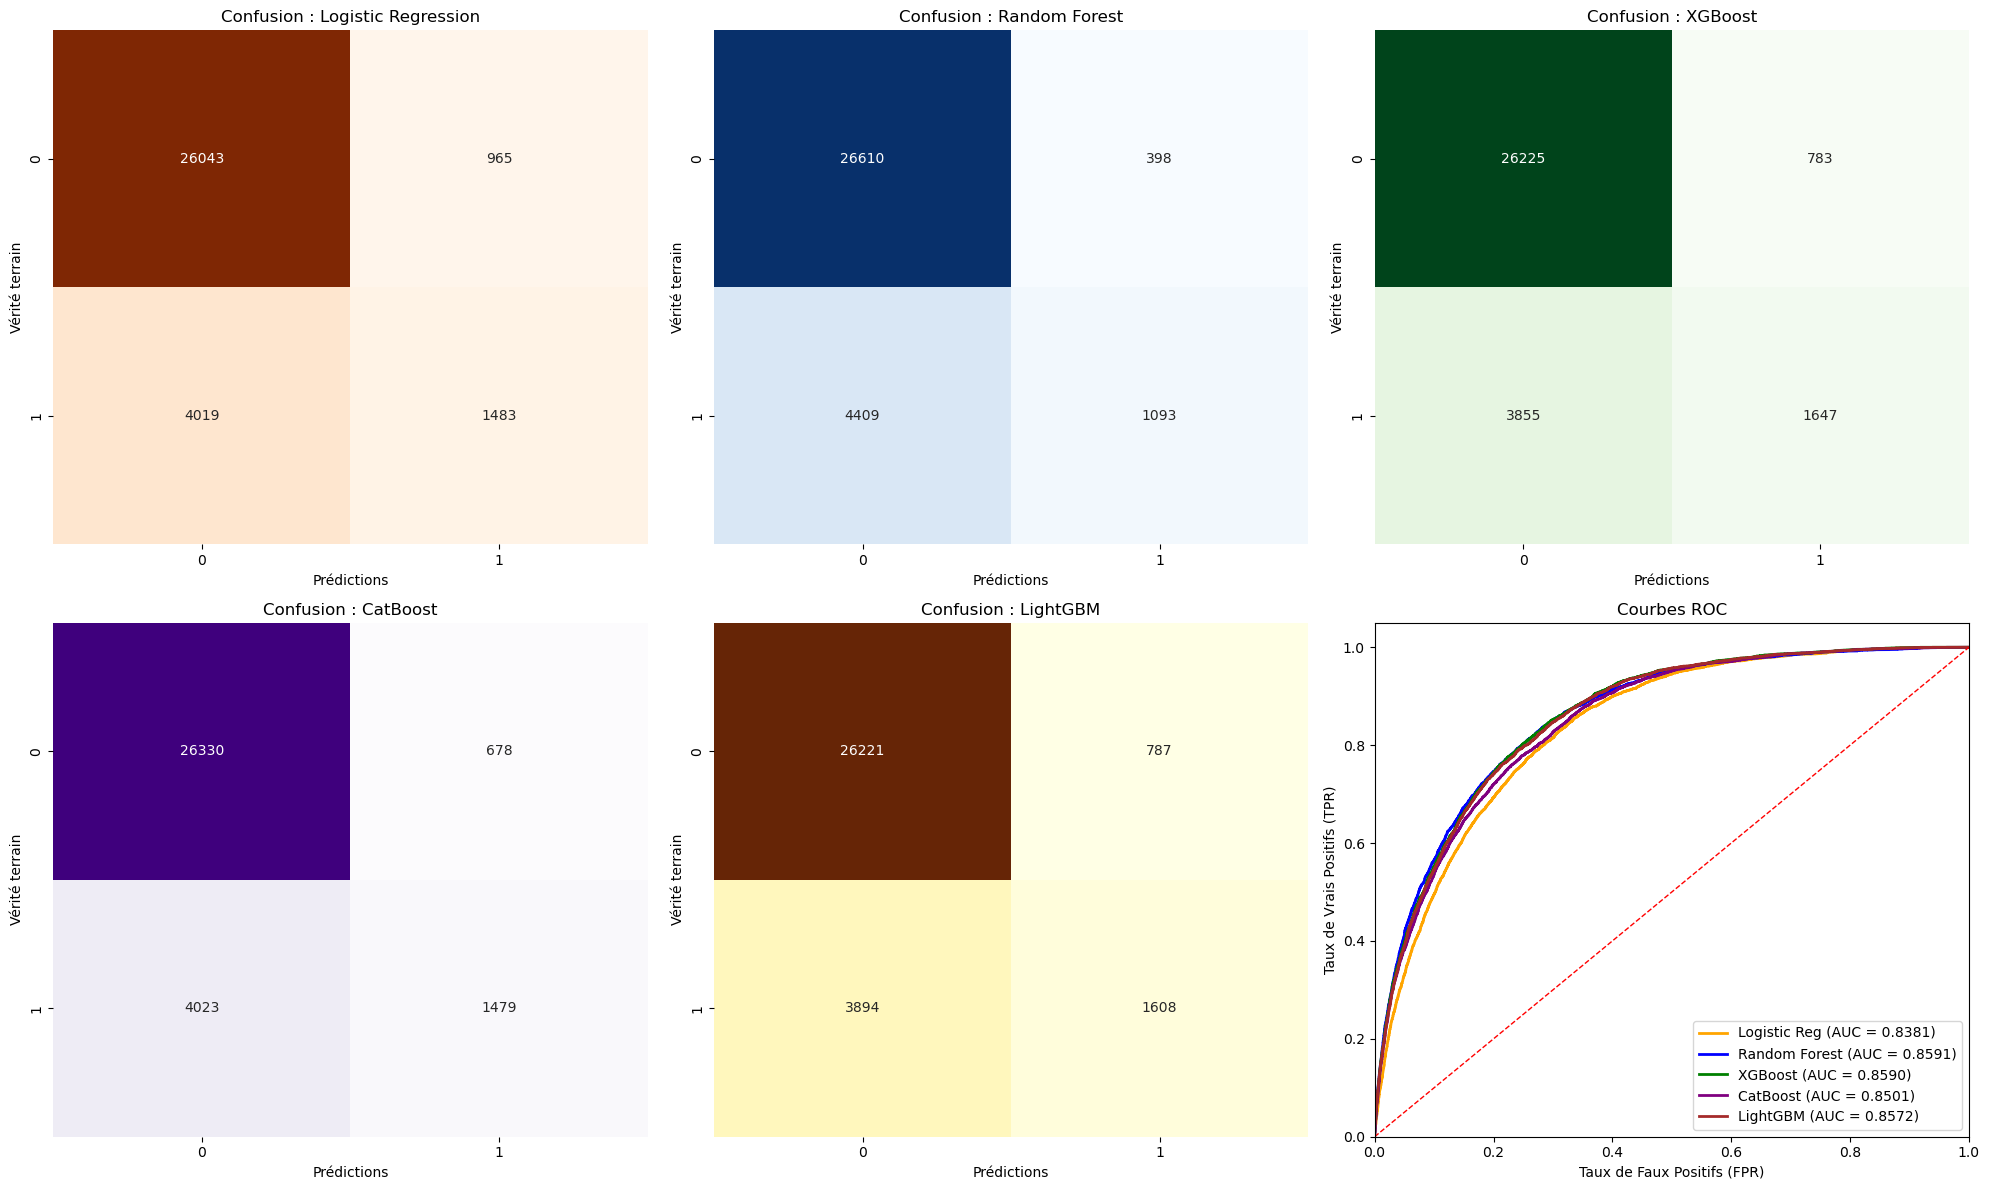

In [19]:
# Graphiques comparatifs (2 lignes, 3 colonnes)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Confusion Matrix Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Confusion : Logistic Regression')
axes[0, 0].set_xlabel('Prédictions')
axes[0, 0].set_ylabel('Vérité terrain')

# 2. Confusion Matrix Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', ax=axes[0, 1], cbar=False)
axes[0, 1].set_title('Confusion : Random Forest')
axes[0, 1].set_xlabel('Prédictions')
axes[0, 1].set_ylabel('Vérité terrain')

# 3. Confusion Matrix XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', ax=axes[0, 2], cbar=False)
axes[0, 2].set_title('Confusion : XGBoost')
axes[0, 2].set_xlabel('Prédictions')
axes[0, 2].set_ylabel('Vérité terrain')

# 4. Confusion Matrix CatBoost
cm_cat = confusion_matrix(y_test, y_pred_cat)
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Purples', ax=axes[1, 0], cbar=False)
axes[1, 0].set_title('Confusion : CatBoost')
axes[1, 0].set_xlabel('Prédictions')
axes[1, 0].set_ylabel('Vérité terrain')

# 5. Confusion Matrix LightGBM
cm_lgb = confusion_matrix(y_test, y_pred_lgb)
sns.heatmap(cm_lgb, annot=True, fmt='d', cmap='YlOrBr', ax=axes[1, 1], cbar=False)
axes[1, 1].set_title('Confusion : LightGBM')
axes[1, 1].set_xlabel('Prédictions')
axes[1, 1].set_ylabel('Vérité terrain')

# 6. Courbes ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

fpr_cat, tpr_cat, _ = roc_curve(y_test, y_prob_cat)
roc_auc_cat = auc(fpr_cat, tpr_cat)

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_prob_lgb)
roc_auc_lgb = auc(fpr_lgb, tpr_lgb)

axes[1, 2].plot(fpr_lr, tpr_lr, color='orange', lw=2, label=f'Logistic Reg (AUC = {roc_auc_lr:.4f})')
axes[1, 2].plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf:.4f})')
axes[1, 2].plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})')
axes[1, 2].plot(fpr_cat, tpr_cat, color='purple', lw=2, label=f'CatBoost (AUC = {roc_auc_cat:.4f})')
axes[1, 2].plot(fpr_lgb, tpr_lgb, color='brown', lw=2, label=f'LightGBM (AUC = {roc_auc_lgb:.4f})')
axes[1, 2].plot([0, 1], [0, 1], color='red', lw=1, linestyle='--')
axes[1, 2].set_xlim([0.0, 1.0])
axes[1, 2].set_ylim([0.0, 1.05])
axes[1, 2].set_xlabel('Taux de Faux Positifs (FPR)')
axes[1, 2].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[1, 2].set_title('Courbes ROC')
axes[1, 2].legend(loc="lower right")
os.makedirs("images", exist_ok=True)
fig.savefig("images/matrix_confusion_&_curve_ROC.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()


# Analyse des matrices de confusion et des courbes ROC

## Matrices de confusion

Les matrices de confusion permettent de visualiser les performances de chaque modèle en comparant les classes réelles aux classes prédites.

- **Régression Logistique** : détecte correctement la majorité des accidents non graves, mais manque un nombre important d'accidents graves (4019 faux négatifs). Ses performances sont donc limitées pour la classe minoritaire.

- **Random Forest** : améliore fortement la détection des accidents non graves (26610 vrais négatifs) mais détecte relativement peu d'accidents graves (1093 vrais positifs). Le modèle privilégie la classe majoritaire.

- **XGBoost** : identifie davantage d'accidents graves (1647 vrais positifs) que Random Forest, au prix d'une légère augmentation des faux positifs. Il offre un meilleur équilibre entre les deux classes.

- **CatBoost** : présente des performances proches de XGBoost mais détecte un peu moins d'accidents graves (1479 vrais positifs).

- **LightGBM** : obtient le plus grand nombre de vrais positifs (1608) tout en conservant un bon niveau de détection des accidents non graves. Il constitue l'un des meilleurs compromis.



---

##  Courbes ROC

Les courbes ROC évaluent la capacité des modèles à distinguer les accidents graves des accidents non graves. Plus la courbe est proche du coin supérieur gauche, plus le modèle est performant.

Les scores AUC obtenus sont :

| Modèle | AUC |
|---------|-----|
| Régression Logistique | 0.838 |
| Random Forest | 0.859 |
| XGBoost | 0.859 |
| CatBoost | 0.850 |
| LightGBM | 0.857 |



Tous les modèles présentent une bonne capacité de discrimination (AUC > 0.83). **Random Forest** et **XGBoost** obtiennent les meilleures valeurs d'AUC, ce qui confirme leur excellente capacité à distinguer les deux classes.

---

## 7. Importance des Variables (Feature Importance)

Nous visualisons les 15 variables les plus importantes pour chaque modèle afin de comprendre les facteurs aggravants de l'accident.

C:\Users\tiaal\AppData\Local\Temp\ipykernel_24944\899419089.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Random_Forest', y='Feature', data=df_rf_top, ax=axes[0, 0], palette='Blues_r')
C:\Users\tiaal\AppData\Local\Temp\ipykernel_24944\899419089.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='XGBoost', y='Feature', data=df_xgb_top, ax=axes[0, 1], palette='Greens_r')
C:\Users\tiaal\AppData\Local\Temp\ipykernel_24944\899419089.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='CatBoost', y='Feature', data=df_cat_top, ax=a

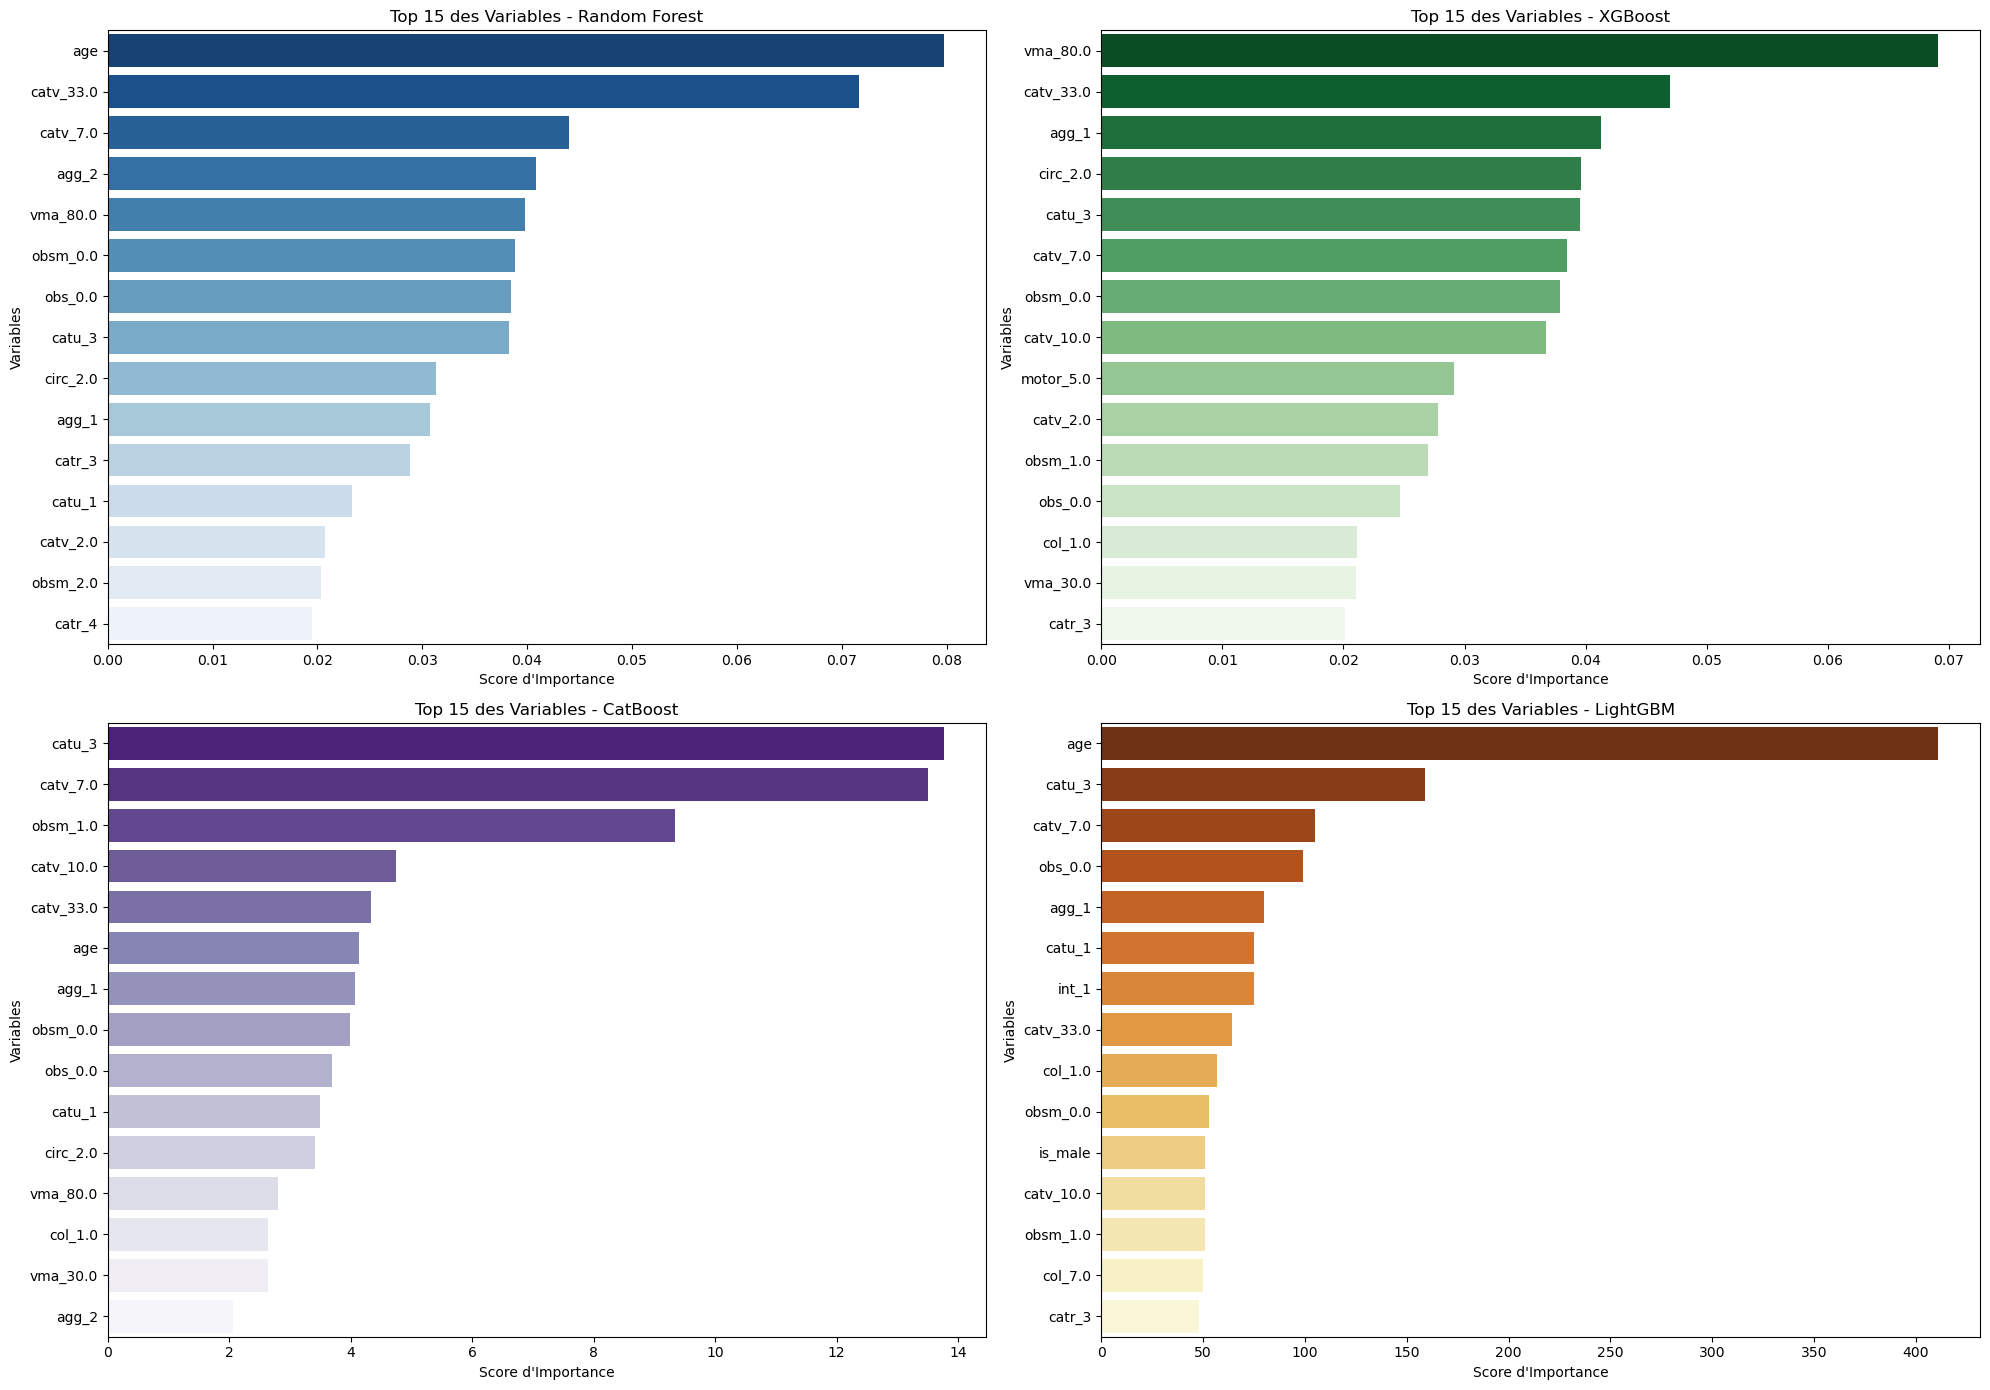

In [20]:
# Récupération des importances de features pour les modèles d'arbres
rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_
cat_importances = cat_model.feature_importances_
lgb_importances = lgb_model.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Random_Forest': rf_importances,
    'XGBoost': xgb_importances,
    'CatBoost': cat_importances,
    'LightGBM': lgb_importances
})

# Tri et sélection du Top 15 pour chaque modèle
df_rf_top = df_importance.sort_values(by='Random_Forest', ascending=False).head(15)
df_xgb_top = df_importance.sort_values(by='XGBoost', ascending=False).head(15)
df_cat_top = df_importance.sort_values(by='CatBoost', ascending=False).head(15)
df_lgb_top = df_importance.sort_values(by='LightGBM', ascending=False).head(15)

# Visualisation en grille
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# 1. Random Forest
sns.barplot(x='Random_Forest', y='Feature', data=df_rf_top, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Top 15 des Variables - Random Forest')
axes[0, 0].set_xlabel('Score d\'Importance')
axes[0, 0].set_ylabel('Variables')

# 2. XGBoost
sns.barplot(x='XGBoost', y='Feature', data=df_xgb_top, ax=axes[0, 1], palette='Greens_r')
axes[0, 1].set_title('Top 15 des Variables - XGBoost')
axes[0, 1].set_xlabel('Score d\'Importance')
axes[0, 1].set_ylabel('Variables')

# 3. CatBoost
sns.barplot(x='CatBoost', y='Feature', data=df_cat_top, ax=axes[1, 0], palette='Purples_r')
axes[1, 0].set_title('Top 15 des Variables - CatBoost')
axes[1, 0].set_xlabel('Score d\'Importance')
axes[1, 0].set_ylabel('Variables')

# 4. LightGBM
sns.barplot(x='LightGBM', y='Feature', data=df_lgb_top, ax=axes[1, 1], palette='YlOrBr_r')
axes[1, 1].set_title('Top 15 des Variables - LightGBM')
axes[1, 1].set_xlabel('Score d\'Importance')
axes[1, 1].set_ylabel('Variables')

os.makedirs("images", exist_ok=True)
fig.savefig("images/features_important.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()




# Analyse de l'importance des variables

Les graphiques présentent les 15 variables les plus importantes utilisées par chaque modèle pour prédire la gravité d'un accident.

## Random Forest

Les variables **âge**, **catv_33.0** et **catv_7.0** apparaissent comme les plus influentes. L'âge est le facteur le plus déterminant selon ce modèle.

**Conclusion :** Random Forest accorde une importance importante aux caractéristiques liées au conducteur et au type de véhicule.

---

## XGBoost

La variable **vma_80.0** (vitesse maximale autorisée) est la plus importante, suivie de **catv_33.0** et **agg_1**.

**Conclusion :** XGBoost met davantage en avant les conditions de circulation et les caractéristiques de l'environnement routier.

---

## CatBoost

Les variables **catu_3**, **catv_7.0** et **obsm_1.0** sont les plus influentes.

**Conclusion :** CatBoost s'appuie principalement sur le rôle de l'usager, le type de véhicule et la présence d'obstacles.

---

## LightGBM

La variable **âge** domine largement devant les autres variables, suivie de **catu_3** et **catv_7.0**.

**Conclusion :** LightGBM considère l'âge comme le facteur le plus déterminant dans la prédiction de la gravité des accidents.

---



Les différents modèles identifient des variables importantes similaires, notamment **l'âge**, **le type de véhicule**, **la vitesse maximale autorisée**, **la catégorie d'usager** et **les caractéristiques de l'environnement routier**. Ces résultats montrent que la gravité d'un accident dépend à la fois des caractéristiques du conducteur, du véhicule et des conditions de circulation.

---
